Experiment: Cats and dogs experiments
Root folder: C:\Users\jakub\Documents\Magisterskie\DeepLearning\project3\report\full_run
Found training files: 3
Parsed epoch rows: 825
Parsed BEST RUN RESULT rows: 3
Saved global tables to: C:\Users\jakub\Documents\Magisterskie\DeepLearning\project3\report\full_run\_training_analysis2_cats_and_dogs_experiments
Differing parameter(s): LR, z, batch size
Seed order: 42 / 142 / 242

Detailed best FID per seed:


,config_display_label,config,seed,best_fid,best_epoch,source_folder,source_file
0,"LR=0.001, z=64, batch size=32",lr=0.001_z=64_bs=32,42,100.89,246,.,training.log
1,"LR=0.001, z=64, batch size=32",lr=0.001_z=64_bs=32,142,95.85,240,.,training (4).log
2,"LR=0.001, z=64, batch size=32",lr=0.001_z=64_bs=32,242,106.35,195,.,training (5).log



Summary for LaTeX:


,config_display_label,fid_mean_std,seed_header,seed_fids,fid_mean,fid_std,best_seed,best_epoch,best_seed_fid,seed_42_fid,seed_142_fid,seed_242_fid
0,"LR=0.001, z=64, batch size=32",101.03 ± 5.25,42 / 142 / 242,100.89 / 95.85 / 106.35,101.03,5.2514,142,240,95.85,100.89,95.85,106.35


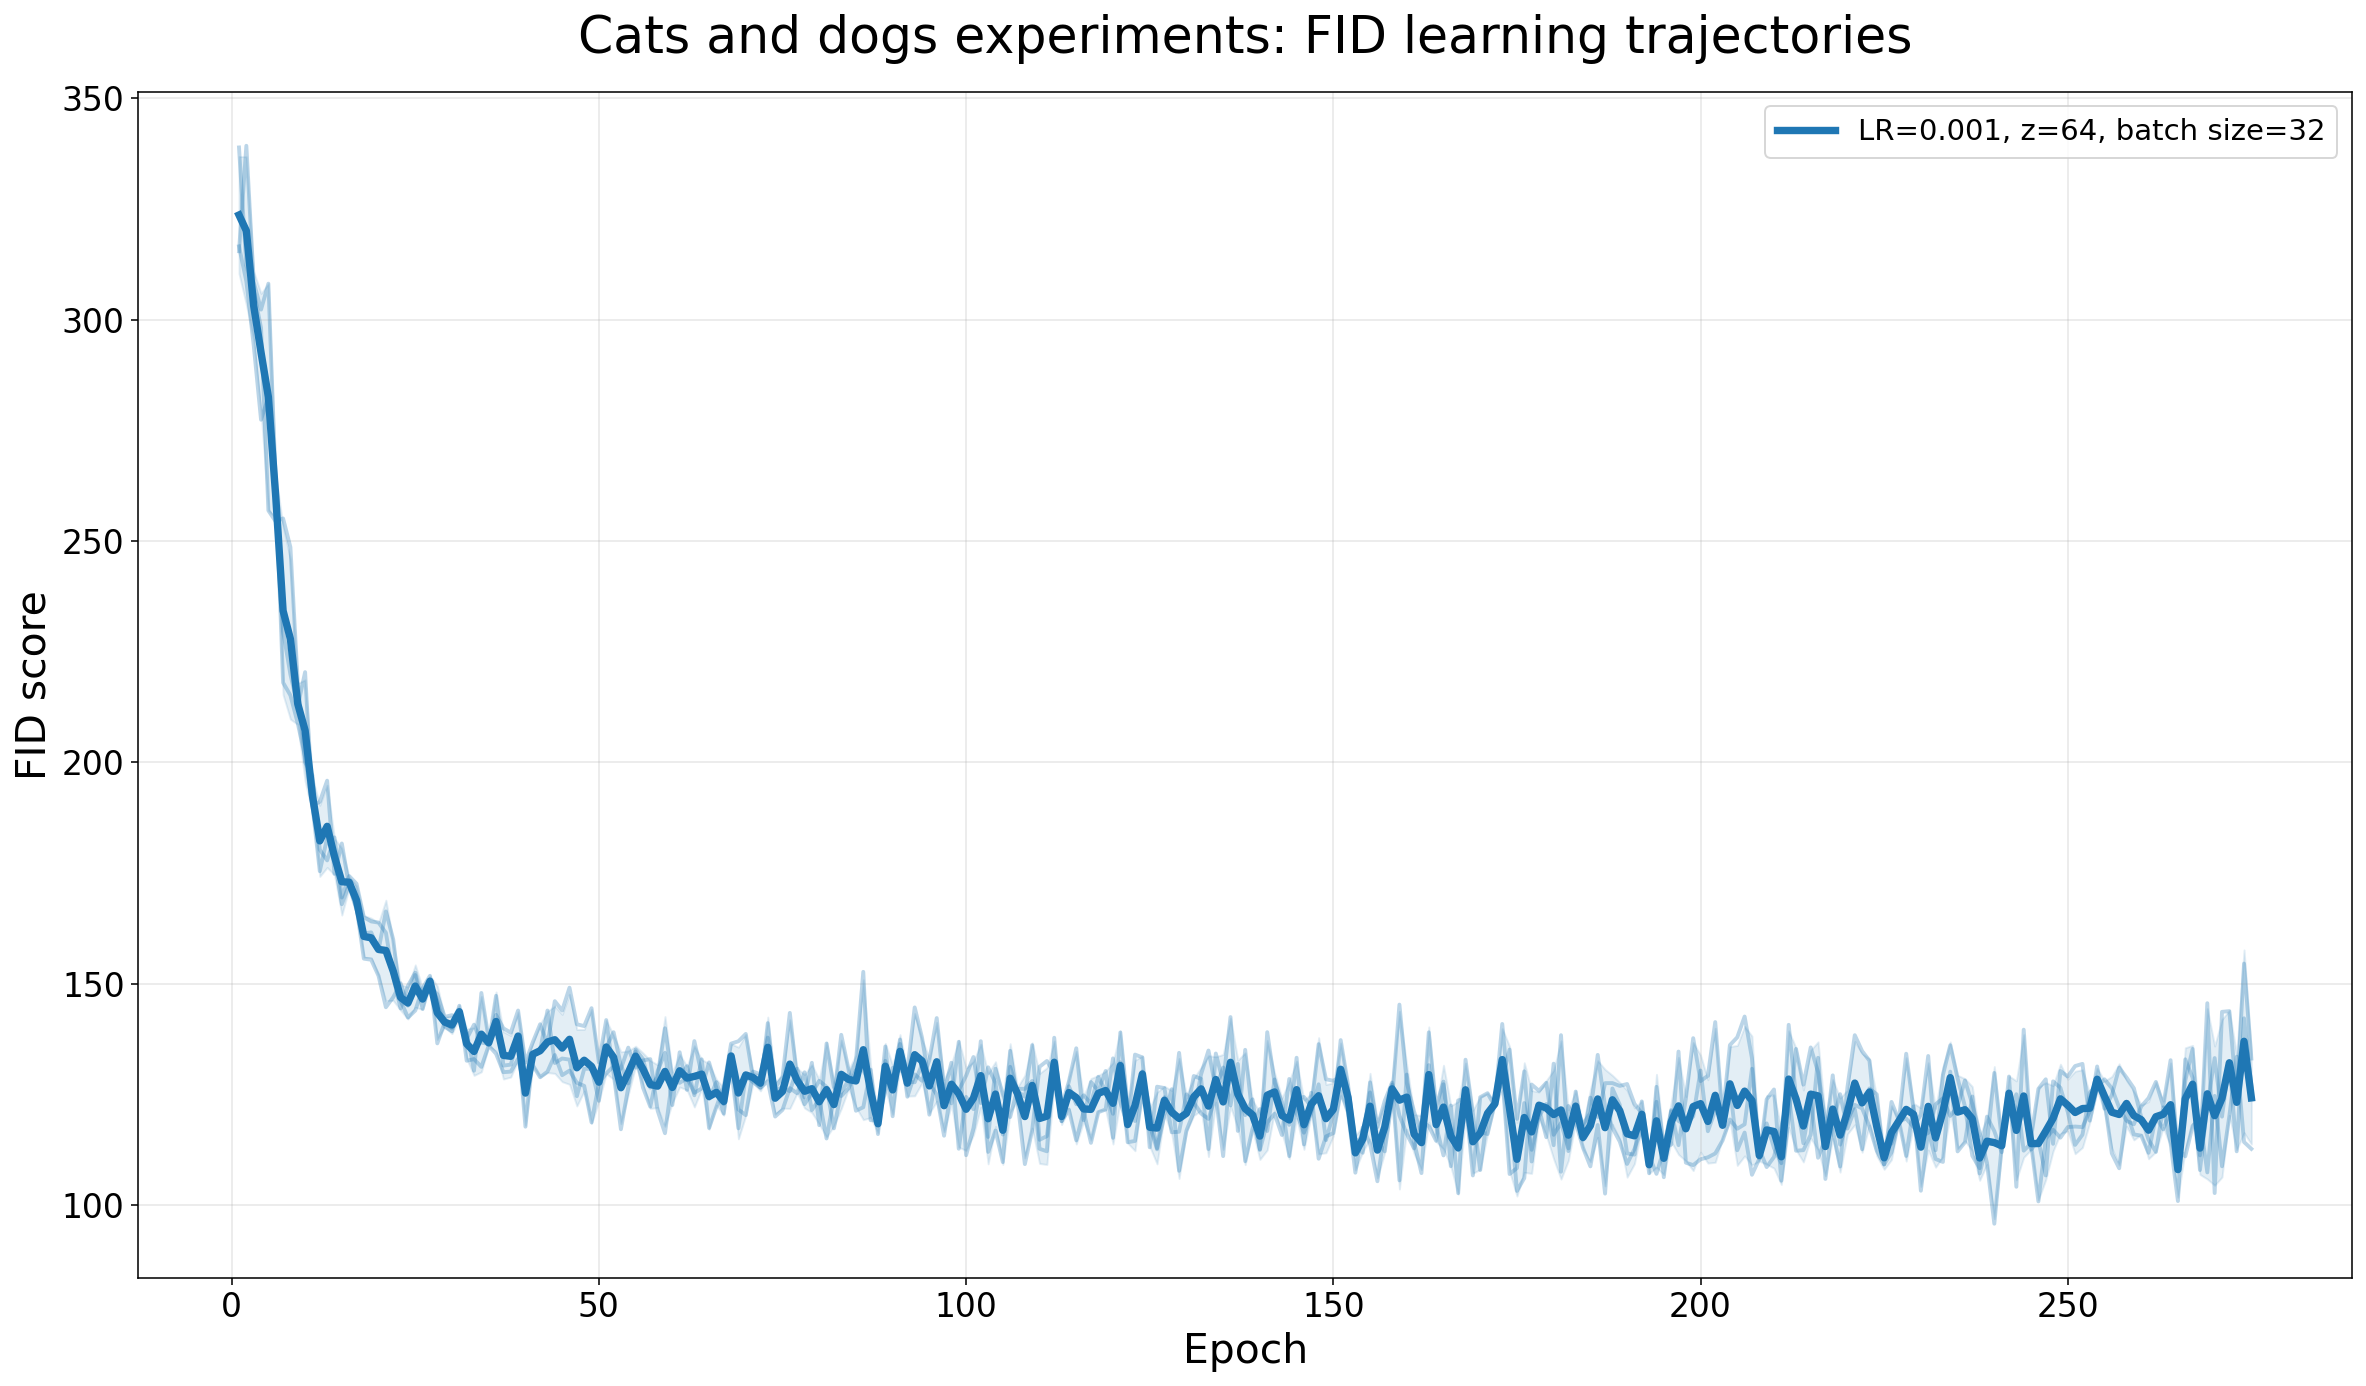

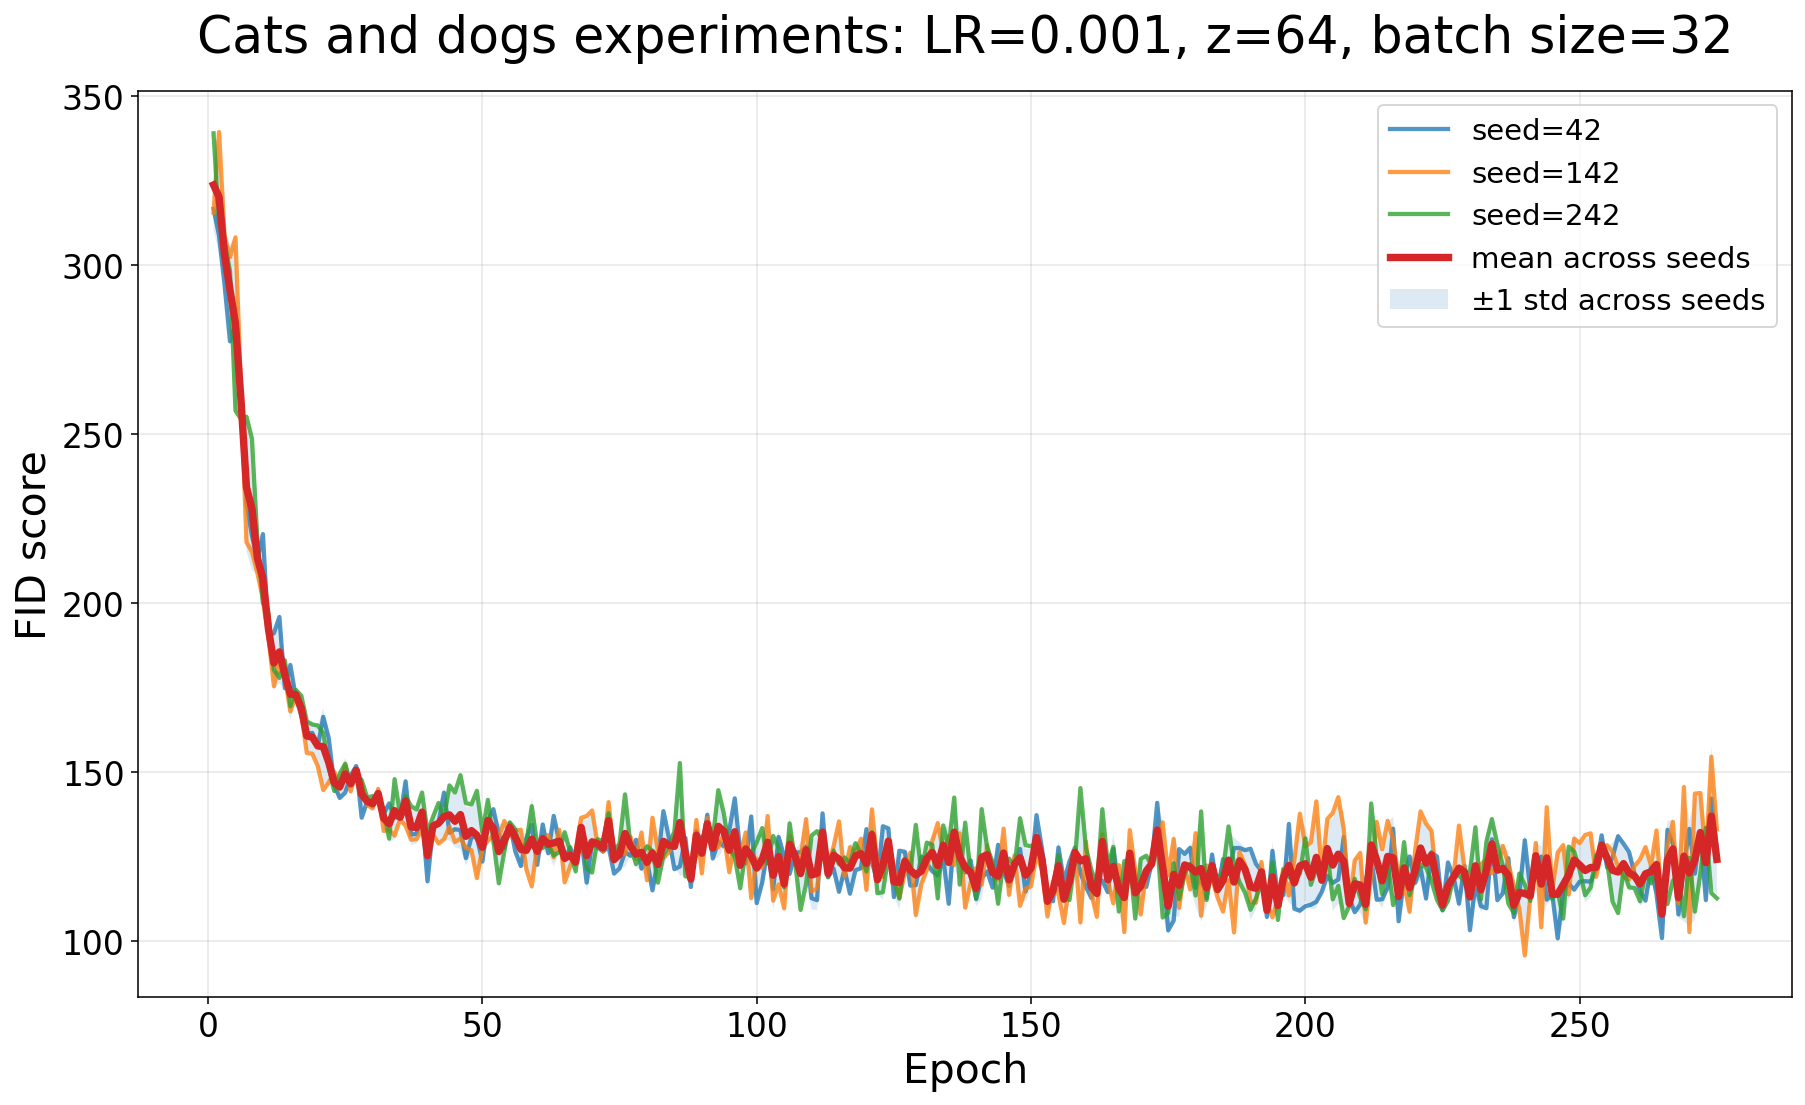

Found sample images: 3
Saved global collage: c:\Users\jakub\Documents\Magisterskie\DeepLearning\project3\report\full_run\_training_analysis2_cats_and_dogs_experiments\best_samples_collage_global_by_config.png

Done.
All outputs are in: C:\Users\jakub\Documents\Magisterskie\DeepLearning\project3\report\full_run\_training_analysis2_cats_and_dogs_experiments


In [2]:
from pathlib import Path
from decimal import Decimal, InvalidOperation
import re
import math
import textwrap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.font_manager import FontProperties

from PIL import Image, ImageDraw, ImageFont, ImageOps


# ============================================================
# User configuration
# ============================================================

# Folder containing all experiment subfolders.
# ROOT = Path.cwd()
ROOT = Path.cwd() / "full_run"

EXPERIMENT_TITLE = "Cats and dogs experiments"

EXPERIMENT_SLUG = re.sub(r"[^A-Za-z0-9]+", "_", EXPERIMENT_TITLE.lower()).strip("_")
OUT = ROOT / f"_training_analysis2_{EXPERIMENT_SLUG}"

TRAINING_PREFIX = "training"
SAMPLE_PREFIX = "samples"

IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".webp", ".bmp"}

MAKE_PER_CONFIG_PLOTS = True
ALLOW_FALLBACK_TO_NON_BEST_SEED_IMAGE = False


# ============================================================
# Display / style settings
# ============================================================

COLLAGE_MAX_COLS = 3
COLLAGE_THUMB_SIZE = (520, 520)
COLLAGE_LABEL_HEIGHT = 210
COLLAGE_PADDING = 28

COLLAGE_TITLE_FONT_SIZE = 46
COLLAGE_HEADER_FONT_SIZE = 34
COLLAGE_BODY_FONT_SIZE = 27
COLLAGE_SMALL_FONT_SIZE = 24

PLOT_TITLE_SIZE = 26
PLOT_LABEL_SIZE = 21
PLOT_TICK_SIZE = 17
PLOT_LEGEND_SIZE = 15
PLOT_LINEWIDTH_MEAN = 3.8
PLOT_LINEWIDTH_SEED = 2.0

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 260,
    "axes.titlesize": PLOT_TITLE_SIZE,
    "axes.labelsize": PLOT_LABEL_SIZE,
    "xtick.labelsize": PLOT_TICK_SIZE,
    "ytick.labelsize": PLOT_TICK_SIZE,
    "legend.fontsize": PLOT_LEGEND_SIZE,
})

OUT.mkdir(exist_ok=True)


# ============================================================
# Regex patterns
# ============================================================

RAW_LR_PATTERN = r"[-+0-9.eE]+"
RUN_ID_PATTERN = rf"lr={RAW_LR_PATTERN}_z=\d+_bs=\d+_seed=\d+"

RUN_RE = re.compile(
    rf"lr=(?P<lr>{RAW_LR_PATTERN})_z=(?P<z>\d+)_bs=(?P<bs>\d+)_seed=(?P<seed>\d+)"
)

EPOCH_RE = re.compile(
    rf"(?P<run_id>{RUN_ID_PATTERN})\s*\|\s*epoch=(?P<epoch>\d+)/(?:\d+).*?\|\s*FID=(?P<fid>[-+0-9.eE]+)"
)

BEST_RE = re.compile(
    rf"BEST RUN RESULT\s*\|\s*(?P<run_id>{RUN_ID_PATTERN})\s*\|\s*best_epoch=(?P<epoch>\d+)\s*\|\s*best_FID=(?P<fid>[-+0-9.eE]+)"
)

SAMPLE_RE = re.compile(
    rf"{SAMPLE_PREFIX}_(?P<run_id>{RUN_ID_PATTERN})_epoch=(?P<epoch>\d+)",
    re.IGNORECASE,
)


# ============================================================
# Helpers
# ============================================================

def canonical_lr(raw_lr: str) -> str:
    """
    Normalizes learning rate strings:
    0.001, 1e-3, 1E-03 -> 0.001
    0.00001, 1e-5, 1E-05 -> 1e-5
    """
    raw_lr = str(raw_lr).strip()

    try:
        value = Decimal(raw_lr)
    except InvalidOperation:
        return raw_lr.lower()

    if value == 0:
        return "0"

    abs_value = abs(value)

    if Decimal("0.0001") <= abs_value < Decimal("1000"):
        s = format(value.normalize(), "f")
        if "." in s:
            s = s.rstrip("0").rstrip(".")
        return s

    s = f"{float(value):.12g}"
    s = s.replace("E", "e")
    s = re.sub(r"e\+?(-?)0*(\d+)", r"e\1\2", s)
    s = s.replace("e+-", "e-")
    return s


def safe_name(x: str) -> str:
    x = str(x).replace("\\", "_").replace("/", "_")
    x = re.sub(r"[^A-Za-z0-9._=+-]+", "_", x)
    return x.strip("_")[:180] or "output"


def parse_timestamp(line: str):
    m = re.match(r"^(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2},\d{3})", line)
    if not m:
        return pd.NaT
    return pd.to_datetime(m.group(1), format="%Y-%m-%d %H:%M:%S,%f", errors="coerce")


def source_folder(path: Path) -> str:
    rel = path.parent.relative_to(ROOT)
    return "." if str(rel) == "." else str(rel)


def get_pil_font(size=24, bold=False):
    """
    Robust font loader. This fixes the tiny title problem from PIL fallback fonts.
    """
    weight = "bold" if bold else "regular"

    for family in ["DejaVu Sans", "Liberation Sans", "Arial"]:
        try:
            prop = FontProperties(family=family, weight=weight)
            font_path = fm.findfont(prop, fallback_to_default=True)
            return ImageFont.truetype(font_path, size=size)
        except Exception:
            pass

    return ImageFont.load_default()


def parse_run_id(run_id: str) -> dict:
    m = RUN_RE.search(run_id)

    if not m:
        raise ValueError(f"Cannot parse run id: {run_id}")

    lr_raw = m.group("lr")
    lr = canonical_lr(lr_raw)

    z = int(m.group("z"))
    bs = int(m.group("bs"))
    seed = int(m.group("seed"))

    config = f"lr={lr}_z={z}_bs={bs}"
    config_label_full = f"LR={lr}, z={z}, batch size={bs}"

    normalized_run_id = f"{config}_seed={seed}"

    return {
        "run_id_raw": run_id,
        "run_id": normalized_run_id,
        "lr_raw": lr_raw,
        "lr": lr,
        "z": z,
        "bs": bs,
        "seed": seed,
        "config": config,
        "config_label_full": config_label_full,
    }


def infer_varying_params(summary_df: pd.DataFrame):
    """
    Detects which hyperparameters differ across configs.
    Usually exactly one parameter differs.
    """
    param_info = [
        ("lr", "LR"),
        ("z", "z"),
        ("bs", "batch size"),
    ]

    varying = []

    for col, label in param_info:
        if col in summary_df.columns and summary_df[col].nunique(dropna=True) > 1:
            varying.append((col, label))

    if len(varying) == 0:
        varying = param_info

    return varying


def make_config_display_label(row, varying_params):
    """
    Shows only the differing parameter, e.g.:
    LR=0.001

    If more than one parameter differs, it shows only those differing parameters.
    """
    parts = []

    for col, label in varying_params:
        value = row[col]
        parts.append(f"{label}={value}")

    return ", ".join(parts)


# ============================================================
# Parse training logs globally
# ============================================================

def find_training_files(root: Path) -> list[Path]:
    return sorted(
        p for p in root.rglob("*")
        if p.is_file() and p.name.lower().startswith(TRAINING_PREFIX.lower())
    )


def parse_training_file(path: Path) -> tuple[list[dict], list[dict]]:
    epoch_rows = []
    best_rows = []

    text = path.read_text(encoding="utf-8", errors="ignore")
    folder = source_folder(path)
    rel_path = str(path.relative_to(ROOT))

    for line_no, line in enumerate(text.splitlines(), start=1):
        ts = parse_timestamp(line)

        m_epoch = EPOCH_RE.search(line)
        if m_epoch:
            info = parse_run_id(m_epoch.group("run_id"))

            epoch_rows.append({
                **info,
                "epoch": int(m_epoch.group("epoch")),
                "fid": float(m_epoch.group("fid")),
                "timestamp": ts,
                "source_folder": folder,
                "source_file": rel_path,
                "line_no": line_no,
            })

        m_best = BEST_RE.search(line)
        if m_best:
            info = parse_run_id(m_best.group("run_id"))

            best_rows.append({
                **info,
                "best_epoch": int(m_best.group("epoch")),
                "best_fid": float(m_best.group("fid")),
                "timestamp": ts,
                "source_folder": folder,
                "source_file": rel_path,
                "line_no": line_no,
                "best_source": "BEST RUN RESULT",
            })

    return epoch_rows, best_rows


training_files = find_training_files(ROOT)

all_epoch_rows = []
all_best_rows = []

for path in training_files:
    epoch_rows, best_rows = parse_training_file(path)
    all_epoch_rows.extend(epoch_rows)
    all_best_rows.extend(best_rows)

epoch_df = pd.DataFrame(all_epoch_rows)
best_events_df = pd.DataFrame(all_best_rows)

if epoch_df.empty and best_events_df.empty:
    raise RuntimeError(
        f"No parsable training logs found under {ROOT}. "
        f"Expected files starting with '{TRAINING_PREFIX}'."
    )

print(f"Experiment: {EXPERIMENT_TITLE}")
print(f"Root folder: {ROOT.resolve()}")
print(f"Found training files: {len(training_files)}")
print(f"Parsed epoch rows: {len(epoch_df)}")
print(f"Parsed BEST RUN RESULT rows: {len(best_events_df)}")


# ============================================================
# Global deduplication and summary tables
# ============================================================

if not epoch_df.empty:
    epoch_df = (
        epoch_df
        .sort_values([
            "config", "seed", "epoch",
            "timestamp", "source_file", "line_no"
        ])
        .drop_duplicates(["config", "seed", "epoch"], keep="last")
        .reset_index(drop=True)
    )

    idx = epoch_df.groupby(["config", "seed"])["fid"].idxmin()

    best_from_epochs = (
        epoch_df.loc[idx, [
            "config", "config_label_full", "lr", "z", "bs", "seed",
            "epoch", "fid", "timestamp", "source_folder", "source_file", "line_no"
        ]]
        .rename(columns={
            "epoch": "best_epoch",
            "fid": "best_fid",
        })
        .assign(best_source="minimum epoch FID")
    )
else:
    best_from_epochs = pd.DataFrame()


best_candidates = []

if not best_from_epochs.empty:
    best_candidates.append(best_from_epochs)

if not best_events_df.empty:
    best_candidates.append(best_events_df)

best_candidates_df = pd.concat(best_candidates, ignore_index=True)

best_by_seed = (
    best_candidates_df
    .sort_values(["config", "seed", "best_fid", "timestamp"])
    .drop_duplicates(["config", "seed"], keep="first")
    .reset_index(drop=True)
)

summary_by_config = (
    best_by_seed
    .groupby(["config", "config_label_full", "lr", "z", "bs"], as_index=False)
    .agg(
        n_seeds=("seed", "nunique"),
        seeds=("seed", lambda x: ", ".join(map(str, sorted(set(x))))),
        fid_mean=("best_fid", "mean"),
        fid_std=("best_fid", lambda x: x.std(ddof=1) if len(x) > 1 else 0.0),
        fid_min=("best_fid", "min"),
        fid_max=("best_fid", "max"),
        source_folders=("source_folder", lambda x: ", ".join(sorted(set(map(str, x))))),
    )
)

best_seed_idx = best_by_seed.groupby("config")["best_fid"].idxmin()

best_seed_per_config = (
    best_by_seed.loc[
        best_seed_idx,
        ["config", "seed", "best_epoch", "best_fid", "source_folder", "source_file"]
    ]
    .rename(columns={
        "seed": "best_seed",
        "best_epoch": "best_epoch",
        "best_fid": "best_seed_fid",
        "source_folder": "best_source_folder",
        "source_file": "best_source_file",
    })
)

summary_by_config = (
    summary_by_config
    .merge(best_seed_per_config, on="config", how="left")
    .sort_values(["fid_mean", "fid_std", "config"])
    .reset_index(drop=True)
)

# ============================================================
# Add readable labels and per-seed FID values
# ============================================================

varying_params = infer_varying_params(summary_by_config)

summary_by_config["config_display_label"] = summary_by_config.apply(
    lambda row: make_config_display_label(row, varying_params),
    axis=1,
)

display_label_map = dict(zip(summary_by_config["config"], summary_by_config["config_display_label"]))

epoch_df["config_display_label"] = epoch_df["config"].map(display_label_map)
best_by_seed["config_display_label"] = best_by_seed["config"].map(display_label_map)


# ------------------------------------------------------------
# Per-seed values for LaTeX table
# ------------------------------------------------------------

seed_order = sorted(best_by_seed["seed"].dropna().astype(int).unique())

seed_pivot = (
    best_by_seed
    .pivot_table(
        index="config",
        columns="seed",
        values="best_fid",
        aggfunc="min"
    )
)

# Add one column per seed, e.g. seed_42_fid, seed_142_fid, seed_242_fid
for seed in seed_order:
    col_name = f"seed_{seed}_fid"
    summary_by_config[col_name] = summary_by_config["config"].map(seed_pivot[seed])


def format_seed_fids(row, seed_order):
    values = []

    for seed in seed_order:
        value = row.get(f"seed_{seed}_fid", np.nan)

        if pd.isna(value):
            values.append("--")
        else:
            values.append(f"{value:.2f}")

    return " / ".join(values)


def format_mean_std(row):
    return f"{row['fid_mean']:.2f} ± {row['fid_std']:.2f}"


summary_by_config["fid_mean_std"] = summary_by_config.apply(format_mean_std, axis=1)

summary_by_config["seed_fids"] = summary_by_config.apply(
    lambda row: format_seed_fids(row, seed_order),
    axis=1,
)

summary_by_config["seed_header"] = " / ".join(map(str, seed_order))


# This is the clean table you should copy and send to me for LaTeX.
summary_for_latex = summary_by_config[
    [
        "config_display_label",
        "fid_mean_std",
        "seed_header",
        "seed_fids",
        "fid_mean",
        "fid_std",
        "best_seed",
        "best_epoch",
        "best_seed_fid",
    ]
    + [f"seed_{seed}_fid" for seed in seed_order]
].copy()


# Save all outputs
epoch_df.to_csv(OUT / "all_epoch_metrics_global.csv", index=False)
best_by_seed.to_csv(OUT / "best_fid_by_seed_global.csv", index=False)
summary_by_config.to_csv(OUT / "summary_by_config_global.csv", index=False)
summary_for_latex.to_csv(OUT / "summary_for_latex.csv", index=False)


print(f"Saved global tables to: {OUT.resolve()}")
print("Differing parameter(s):", ", ".join(label for _, label in varying_params))
print(f"Seed order: {' / '.join(map(str, seed_order))}")

print("\nDetailed best FID per seed:")
try:
    display(best_by_seed.sort_values(["config", "seed"])[
        [
            "config_display_label",
            "config",
            "seed",
            "best_fid",
            "best_epoch",
            "source_folder",
            "source_file",
        ]
    ])
except NameError:
    print(best_by_seed.sort_values(["config", "seed"])[
        [
            "config_display_label",
            "config",
            "seed",
            "best_fid",
            "best_epoch",
            "source_folder",
            "source_file",
        ]
    ])


print("\nSummary for LaTeX:")
try:
    display(summary_for_latex)
except NameError:
    print(summary_for_latex)


# ============================================================
# Global learning trajectory plots
# ============================================================

def plot_global_trajectories(epoch_df: pd.DataFrame, summary_df: pd.DataFrame, out_dir: Path):
    if epoch_df.empty:
        return None

    df = epoch_df.copy()

    config_order = (
        summary_df
        .sort_values(["fid_mean", "fid_std", "config"])
        ["config"]
        .tolist()
    )

    cmap = plt.get_cmap("tab20", max(len(config_order), 1))

    fig, ax = plt.subplots(figsize=(17, 10))

    for i, config in enumerate(config_order):
        color = cmap(i)
        dfg = df[df["config"] == config]

        if dfg.empty:
            continue

        label = dfg["config_display_label"].iloc[0]

        pivot = (
            dfg
            .pivot_table(index="epoch", columns="seed", values="fid", aggfunc="mean")
            .sort_index()
        )

        mean = pivot.mean(axis=1, skipna=True)
        std = pivot.std(axis=1, skipna=True).fillna(0)

        for seed in pivot.columns:
            ax.plot(
                pivot.index,
                pivot[seed],
                color=color,
                alpha=0.30,
                linewidth=PLOT_LINEWIDTH_SEED,
            )

        ax.plot(
            mean.index,
            mean,
            color=color,
            linewidth=PLOT_LINEWIDTH_MEAN,
            label=f"{label}",
        )

        if pivot.shape[1] > 1:
            ax.fill_between(
                mean.index,
                mean - std,
                mean + std,
                color=color,
                alpha=0.12,
            )

    ax.set_title(f"{EXPERIMENT_TITLE}: FID learning trajectories", pad=20, fontsize=PLOT_TITLE_SIZE)
    ax.set_xlabel("Epoch", fontsize=PLOT_LABEL_SIZE)
    ax.set_ylabel("FID score", fontsize=PLOT_LABEL_SIZE)

    ax.tick_params(axis="both", labelsize=PLOT_TICK_SIZE)
    ax.grid(True, alpha=0.3)

    ax.legend(
        fontsize=PLOT_LEGEND_SIZE,
        frameon=True,
        loc="best"
    )

    fig.tight_layout()

    path = out_dir / "fid_learning_trajectories_global.png"
    fig.savefig(path, dpi=260, bbox_inches="tight")
    plt.show()

    return path


def plot_per_config_trajectories(epoch_df: pd.DataFrame, summary_df: pd.DataFrame, out_dir: Path):
    if epoch_df.empty:
        return []

    paths = []

    config_order = (
        summary_df
        .sort_values(["fid_mean", "fid_std", "config"])
        ["config"]
        .tolist()
    )

    for config in config_order:
        df = epoch_df[epoch_df["config"] == config].copy()

        if df.empty:
            continue

        label = df["config_display_label"].iloc[0]

        pivot = (
            df
            .pivot_table(index="epoch", columns="seed", values="fid", aggfunc="mean")
            .sort_index()
        )

        mean = pivot.mean(axis=1, skipna=True)
        std = pivot.std(axis=1, skipna=True).fillna(0)

        fig, ax = plt.subplots(figsize=(13, 8))

        for seed in pivot.columns:
            ax.plot(
                pivot.index,
                pivot[seed],
                linewidth=2.2,
                alpha=0.78,
                label=f"seed={seed}",
            )

        ax.plot(
            mean.index,
            mean,
            linewidth=3.8,
            label="mean across seeds",
        )

        if pivot.shape[1] > 1:
            ax.fill_between(
                mean.index,
                mean - std,
                mean + std,
                alpha=0.15,
                label="±1 std across seeds",
            )

        ax.set_title(f"{EXPERIMENT_TITLE}: {label}", pad=20, fontsize=PLOT_TITLE_SIZE)
        ax.set_xlabel("Epoch", fontsize=PLOT_LABEL_SIZE)
        ax.set_ylabel("FID score", fontsize=PLOT_LABEL_SIZE)

        ax.tick_params(axis="both", labelsize=PLOT_TICK_SIZE)
        ax.grid(True, alpha=0.3)

        ax.legend(
            fontsize=PLOT_LEGEND_SIZE,
            frameon=True,
            loc="best"
        )

        fig.tight_layout()

        path = out_dir / f"fid_learning_trajectory_{safe_name(config)}.png"
        fig.savefig(path, dpi=260, bbox_inches="tight")
        plt.show()

        paths.append(path)

    return paths


plot_global_trajectories(epoch_df, summary_by_config, OUT)

if MAKE_PER_CONFIG_PLOTS:
    plot_per_config_trajectories(epoch_df, summary_by_config, OUT)


# ============================================================
# Sample image indexing
# ============================================================

def find_sample_images(root: Path) -> pd.DataFrame:
    rows = []

    for path in root.rglob("*"):
        if not path.is_file():
            continue

        if path.suffix.lower() not in IMAGE_EXTENSIONS:
            continue

        if not path.name.lower().startswith(SAMPLE_PREFIX.lower()):
            continue

        m = SAMPLE_RE.search(path.stem)

        if not m:
            continue

        info = parse_run_id(m.group("run_id"))

        rows.append({
            **info,
            "image_epoch": int(m.group("epoch")),
            "image_path": path,
            "image_folder": source_folder(path),
        })

    return pd.DataFrame(rows)


samples_df = find_sample_images(ROOT)

print(f"Found sample images: {len(samples_df)}")

if not samples_df.empty:
    samples_df.assign(
        image_path=samples_df["image_path"].apply(lambda p: str(Path(p).relative_to(ROOT)))
    ).to_csv(
        OUT / "sample_images_index_global.csv",
        index=False,
    )


# ============================================================
# Global collage of best runs per config
# ============================================================

def make_text_tile(text: str, size=COLLAGE_THUMB_SIZE):
    img = Image.new("RGB", size, "white")
    draw = ImageDraw.Draw(img)

    title_font = get_pil_font(30, bold=True)
    body_font = get_pil_font(25, bold=False)

    draw.rectangle([0, 0, size[0] - 1, size[1] - 1], outline="black", width=3)

    lines = []
    for line in text.split("\n"):
        lines.extend(textwrap.wrap(line, width=28) or [""])

    y = 28
    for i, line in enumerate(lines[:12]):
        font = title_font if i == 0 else body_font
        draw.text((24, y), line, fill="black", font=font)
        y += 34

    return img


def choose_image_for_best_config(best_row: pd.Series, samples_df: pd.DataFrame):
    if samples_df.empty:
        return None

    config = best_row["config"]
    best_seed = int(best_row["best_seed"])
    best_epoch = int(best_row["best_epoch"])

    candidates = samples_df[samples_df["config"] == config].copy()

    if candidates.empty:
        return None

    best_seed_candidates = candidates[candidates["seed"] == best_seed].copy()

    if not best_seed_candidates.empty:
        candidates = best_seed_candidates
    elif not ALLOW_FALLBACK_TO_NON_BEST_SEED_IMAGE:
        return None

    candidates["epoch_distance"] = (candidates["image_epoch"] - best_epoch).abs()
    candidates = candidates.sort_values(["epoch_distance", "image_epoch", "image_path"])

    return candidates.iloc[0]


def create_global_best_config_collage(
    summary_by_config: pd.DataFrame,
    samples_df: pd.DataFrame,
    out_dir: Path,
    thumb_size=COLLAGE_THUMB_SIZE,
    label_height=COLLAGE_LABEL_HEIGHT,
    padding=COLLAGE_PADDING,
    max_cols=COLLAGE_MAX_COLS,
):
    df = summary_by_config.sort_values(["fid_mean", "fid_std", "config"]).reset_index(drop=True)

    selected_rows = []

    for _, row in df.iterrows():
        chosen = choose_image_for_best_config(row, samples_df)

        record = row.to_dict()

        if chosen is not None:
            record["selected_image"] = str(Path(chosen["image_path"]).relative_to(ROOT))
            record["selected_image_epoch"] = int(chosen["image_epoch"])
            record["selected_image_seed"] = int(chosen["seed"])
        else:
            record["selected_image"] = None
            record["selected_image_epoch"] = None
            record["selected_image_seed"] = None

        selected_rows.append(record)

    selected_df = pd.DataFrame(selected_rows)
    selected_df.to_csv(out_dir / "selected_best_images_for_global_collage.csv", index=False)

    n = len(selected_rows)

    if n == 0:
        return None

    cols = min(max_cols, n)
    rows = math.ceil(n / cols)

    tile_w, tile_h = thumb_size

    title_height = 110
    canvas_w = cols * tile_w + (cols + 1) * padding
    canvas_h = title_height + rows * (tile_h + label_height) + (rows + 1) * padding

    canvas = Image.new("RGB", (canvas_w, canvas_h), "white")
    draw = ImageDraw.Draw(canvas)

    title_font = get_pil_font(COLLAGE_TITLE_FONT_SIZE, bold=True)
    header_font = get_pil_font(COLLAGE_HEADER_FONT_SIZE, bold=True)
    body_font = get_pil_font(COLLAGE_BODY_FONT_SIZE, bold=False)
    small_font = get_pil_font(COLLAGE_SMALL_FONT_SIZE, bold=False)

    title = f"{EXPERIMENT_TITLE}: generated samples"
    title_bbox = draw.textbbox((0, 0), title, font=title_font)
    title_w = title_bbox[2] - title_bbox[0]

    draw.text(
        ((canvas_w - title_w) // 2, 28),
        title,
        fill="black",
        font=title_font,
    )

    for i, item in enumerate(selected_rows):
        r = i // cols
        c = i % cols

        x = padding + c * (tile_w + padding)
        y = title_height + padding + r * (tile_h + label_height + padding)

        draw.rectangle(
            [x - 4, y - 4, x + tile_w + 4, y + tile_h + label_height + 4],
            fill="white",
            outline="black",
            width=3,
        )

        image_path = item.get("selected_image")

        if image_path:
            full_path = ROOT / image_path

            try:
                img = Image.open(full_path).convert("RGB")
                img = ImageOps.contain(img, thumb_size)

                tile = Image.new("RGB", thumb_size, "white")
                paste_x = (tile_w - img.width) // 2
                paste_y = (tile_h - img.height) // 2
                tile.paste(img, (paste_x, paste_y))

            except Exception as e:
                tile = make_text_tile(
                    f"Could not open image\n{image_path}\n{e}",
                    thumb_size,
                )
        else:
            tile = make_text_tile(
                f"No image found\n{item['config_display_label']}\n"
                f"best seed={item['best_seed']}\n"
                f"best epoch={item['best_epoch']}",
                thumb_size,
            )

        canvas.paste(tile, (x, y))

        sep_y = y + tile_h + 8
        draw.line((x, sep_y, x + tile_w, sep_y), fill="black", width=2)

        text_y = y + tile_h + 22

        # Only differing parameter, large and readable.
        header = str(item["config_display_label"])
        header_lines = textwrap.wrap(header, width=22) or [header]

        for line in header_lines[:2]:
            draw.text((x + 18, text_y), line, fill="black", font=header_font)
            text_y += 42

        text_y += 4

        body_lines = [
            f"Best seed: {int(item['best_seed'])}   Epoch: {int(item['best_epoch'])}",
            f"Best FID: {item['best_seed_fid']:.2f}",
            f"Mean FID: {item['fid_mean']:.2f}   Std: {item['fid_std']:.2f}",
        ]

        for line in body_lines:
            draw.text((x + 18, text_y), line, fill="black", font=body_font)
            text_y += 34

    out_path = out_dir / "best_samples_collage_global_by_config.png"
    canvas.save(out_path, quality=95)

    return out_path


collage_path = create_global_best_config_collage(
    summary_by_config=summary_by_config,
    samples_df=samples_df,
    out_dir=OUT,
)

if collage_path is not None:
    print(f"Saved global collage: {collage_path}")


print("\nDone.")
print(f"All outputs are in: {OUT.resolve()}")